<a href="https://colab.research.google.com/github/whbello/Algoritmos-de-optimizaci-n/blob/main/AG3_Algoritmos(Colonia_de_Hormigas).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AG3 - Actividad<br>
Nombre: Wilson Bello V.<br>
Link: https://drive.google.com/drive/folders/1pXG7o4RtxqaONwFa3zGyzJCySFHfHJM9?usp=sharing<br>
Github: https://github.com/whbello/Algoritmos-de-optimizaci-n.git

Se utilizó la misma técnica para elaborar el scrip de la AG3, se trabajo local y en el mismo entorno virtual.

In [ ]:
#Modulo de llamadas http para descargar ficheros
!pip install requests

#Libreria del problema TSP: http://elib.zib.de/pub/mp-testdata/tsp/tsplib/tsplib.html
!pip install tsplib95

In [ ]:
import tsplib95
import random
from math import e
import urllib.request
import os

Al ejecutar el código de la celda a continuación presenta error `TimeoutError` significa que el servidor de la Universidad de Heidelberg no está respondiendo. Consultando en internet se descargo el archivo desde una fuente alternativa (código mas abajo).

In [ ]:
#DATOS DEL PROBLEMA
file = "swiss42.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/swiss42.tsp.gz", file + '.gz')
!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion(lista de nodos)
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)


URLError: <urlopen error [WinError 10060] Se produjo un error durante el intento de conexión ya que la parte conectada no respondió adecuadamente tras un periodo de tiempo, o bien se produjo un error en la conexión establecida ya que el host conectado no ha podido responder>

In [ ]:
# Con este código alternativo se descargo el fichero swiss42.tsp desde una fuente alternativa,
# ya que la fuente original no estaba disponible. Se intentó descargar desde dos URLs diferentes,
# y se manejaron las excepciones para informar sobre cualquier fallo en la descarga.
# Si ninguna de las descargas fue exitosa, se imprime un mensaje indicando que no se pudo descargar
# automáticamente.

file = "swiss42.tsp"

# Intentar descarga desde fuente alternativa
urls = [
    "https://raw.githubusercontent.com/mastqe/tsplib/master/swiss42.tsp",
    "http://elib.zib.de/pub/mp-testdata/tsp/tsplib/tsp/swiss42.tsp"
]

descargado = False
for url in urls:
    try:
        print(f"Intentando descargar desde: {url}")
        urllib.request.urlretrieve(url, file)
        print("Descarga exitosa.")
        descargado = True
        break
    except Exception as e:
        print(f"Falló: {e}")

if not descargado:
    print("No se pudo descargar automáticamente.")

Intentando descargar desde: https://raw.githubusercontent.com/mastqe/tsplib/master/swiss42.tsp
Descarga exitosa.


In [ ]:
# Carga elarchivo
file = "swiss42.tsp"
problem = tsplib95.load(file)

In [ ]:
# Nodos
Nodos = list(problem.get_nodes())

# Devuelve la distancia entre dos nodos
def distancia(a, b, problem):
    return problem.get_weight(a, b)

# Devuelve la distancia total de una trayectoria/solución
def distancia_total(solucion, problem):
    total = 0
    for i in range(len(solucion) - 1):
        total += distancia(solucion[i], solucion[i+1], problem)
    return total + distancia(solucion[-1], solucion[0], problem)

print(f"Problema cargado correctamente: {len(Nodos)} nodos")


Problema cargado correctamente: 42 nodos


## Algoritmo de colonia de hormigas

La función Add_Nodo selecciona al azar un nodo con probabilidad uniforme.
Para ser mas eficiente debería seleccionar el próximo nodo siguiendo la probabilidad correspondiente a la ecuación:

$p^k_{ij}(t) = \frac{[\tau_{ij}(t)]^\alpha[\nu_{ij}]^\beta}{\sum_{l\in J^k_i} [\tau_{il}(t)]^\alpha[\nu_{il}]^\beta}$, si $j \in J^k_i$

$p^k_{ij}(t) = 0$, si $j \notin J^k_i$

### <span style="color:orange">Mejora:</span> Función de Selección del Siguiente Nodo (Add_Nodo)

### Implementación Original
La función original selecciona el siguiente nodo de forma **completamente aleatoria**
con probabilidad uniforme entre los nodos no visitados.

Esta implementación ignora completamente tanto las feromonas depositadas en las
aristas como las distancias entre nodos, desperdiciando toda la información
acumulada por las hormigas anteriores y haciendo que el algoritmo se comporte
como una búsqueda aleatoria pura, sin capacidad de aprendizaje colectivo.

### Implementación Mejorada: Regla de Transición Probabilística ACO
La mejora implementa la **regla de transición probabilística** propuesta por
Dorigo et al. (1996), que es el núcleo matemático del algoritmo ACO:

$$p^k_{ij}(t) = \frac{[\tau_{ij}(t)]^\alpha[\nu_{ij}]^\beta}{\sum_{l\in J^k_i} [\tau_{il}(t)]^\alpha[\nu_{il}]^\beta}$$

Donde:
- $\tau_{ij}(t)$: Cantidad de feromona en la arista (i→j) en el instante t
- $\nu_{ij} = \frac{1}{d_{ij}}$: Visibilidad, inverso de la distancia entre nodos i y j
- $\alpha$: Parámetro que controla la influencia de las feromonas
- $\beta$: Parámetro que controla la influencia de la visibilidad (distancia)
- $J^k_i$: Conjunto de nodos no visitados por la hormiga k desde el nodo i

### Interpretación de los parámetros α y β
- Si **α > β**: Las hormigas priorizan las rutas con más feromonas (explotación).
- Si **β > α**: Las hormigas priorizan las rutas más cortas (exploración).
- El balance entre α y β controla el equilibrio entre exploración y explotación.

### ¿Por qué es mejor?
La versión original asigna la misma probabilidad a todos los nodos no visitados,
ignorando que algunas rutas son más cortas y que algunas aristas tienen más
feromonas acumuladas. La versión mejorada considera ambos factores simultáneamente,
permitiendo que el algoritmo aprenda de las soluciones anteriores y converja
hacia rutas de menor distancia total.


In [ ]:
"""def Add_Nodo(problem, H ,T ) :
  #Mejora:Establecer una funcion de probabilidad para
  # añadir un nuevo nodo dependiendo de los nodos mas cercanos y de las feromonas depositadas
  Nodos = list(problem.get_nodes())
  return random.choice(   list(set(range(1,len(Nodos))) - set(H) )  )


def Incrementa_Feromona(problem, T, H ) :
  #Incrementa segun la calidad de la solución. Añadir una cantidad inversamente proporcional a la distancia total
  for i in range(len(H)-1):
    T[H[i]][H[i+1]] += 1000/distancia_total(H, problem)
  return T

def Evaporar_Feromonas(T ):
  #Evapora 0.3 el valor de la feromona, sin que baje de 1
  #Mejora:Podemos elegir diferentes funciones de evaporación dependiendo de la cantidad actual y de la suma total de feromonas depositadas,...
  T = [[ max(T[i][j] - 0.3 , 1) for i in range(len(Nodos)) ] for j in range(len(Nodos))]
  return T
"""
ALPHA = 1  # Influencia de las feromonas (explotación)
BETA  = 3  # Influencia de la visibilidad/distancia (exploración)

def Add_Nodo(problem, H, T):
    Nodos = list(problem.get_nodes())

    nodo_actual = H[-1] # Nodo actual (último nodo visitado por la hormiga)

    nodos_disponibles = list(set(range(1, len(Nodos))) - set(H)) # Nodos disponibles (no visitados aún)

    # Si solo hay un nodo disponible, se selecciona directamente
    if len(nodos_disponibles) == 1:
        return nodos_disponibles[0]

    # Calcular el peso de cada nodo disponible según la fórmula ACO
    pesos = []
    for j in nodos_disponibles:
        feromona   = T[nodo_actual][j] ** ALPHA
        d = distancia(nodo_actual, j, problem)
        visibilidad = (1.0 / d) ** BETA if d > 0 else 1.0
        pesos.append(feromona * visibilidad)

    # Calcular la probabilidad normalizada de cada nodo disponible
    total = sum(pesos)
    probabilidades = [p / total for p in pesos]

    # Seleccionar el siguiente nodo según las probabilidades calculadas
    return random.choices(nodos_disponibles, weights=probabilidades, k=1)[0]

### Función de Evaporación de Feromonas (Evaporar_Feromonas)

La mejora implementa la **evaporación proporcional** estándar en ACO, propuesta
por Dorigo et al. (1996):

$$\tau_{ij}(t+1) = (1 - \rho) \cdot \tau_{ij}(t)$$

Donde:
- $\rho \in (0,1)$: Tasa de evaporación (valor típico entre 0.1 y 0.5)
- $(1-\rho)$: Factor de retención de feromona

### ¿Por qué es mejor?
La evaporación proporcional garantiza que todas las aristas pierdan el mismo
**porcentaje** de feromona en cada iteración, independientemente de su nivel
actual. Esto produce un comportamiento matemáticamente coherente donde:

- Las aristas con **mucha feromona** evaporan más en términos absolutos
- Las aristas con **poca feromona** evaporan menos en términos absolutos
- Nunca se llega a cero, ya que es una reducción multiplicativa
- El sistema mantiene un **equilibrio dinámico** entre exploración y explotación

Adicionalmente, se elimina el piso arbitrario de 1, permitiendo que las
feromonas converjan naturalmente hacia valores bajos en rutas poco utilizadas.


In [ ]:
# Tasa de evaporación de feromonas (valor entre 0 y 1)
# Valores altos (ej: 0.5) favorecen la exploración de nuevas rutas
# Valores bajos (ej: 0.1) favorecen la explotación de rutas conocidas
RHO = 0.3

def Evaporar_Feromonas(T):
    T = [[(1 - RHO) * T[i][j] for j in range(len(T[i]))] for i in range(len(T))]
    return T

#### La función: solución_greedy
Construye una solución inicial usando el algoritmo del vecino más cercano.
Se usa para calibrar la inicialización de feromonas.

La mejora inicializa las feromonas con un valor proporcional a la calidad de
una **solución greedy** (vecino más cercano), siguiendo la estrategia propuesta
por Dorigo & Gambardella (1997):

$$\tau_0 = \frac{1}{n \cdot L_{greedy}}$$

Donde:
- $n$: Número de nodos del problema
- $L_{greedy}$: Distancia total de la solución greedy (vecino más cercano)

**Es mejor por qué**:
Inicializa con $\tau_0$ basado en una solución greedy proporciona al algoritmo
un **punto de partida informado** en lugar de uno completamente arbitrario.

Mejor solución: [0, 1, 6, 4, 3, 2, 27, 28, 8, 10, 25, 23, 41, 9, 40, 21, 38, 22, 33, 20, 34, 13, 19, 14, 16, 15, 37, 7, 32, 30, 29, 11, 12, 18, 26, 5, 36, 17, 31, 35, 39, 24]
Mejor distancia: 2154
Construyendo matriz de distancias...
Calculando coordenadas 2D con MDS...


d:\Work\Cursos\IA\U_Valencia_Master_IA\03. Algoritmos de Optimización\Actividad Guiada 1 y 2\AG3\tsp_env\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\Work\Cursos\IA\U_Valencia_Master_IA\03. Algoritmos de Optimización\Actividad Guiada 1 y 2\AG3\tsp_env\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\Work\Cursos\IA\U_Valencia_Master_IA\03. Algoritmos de Optimización\Actividad Guiada 1 y 2\AG3\tsp_env\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


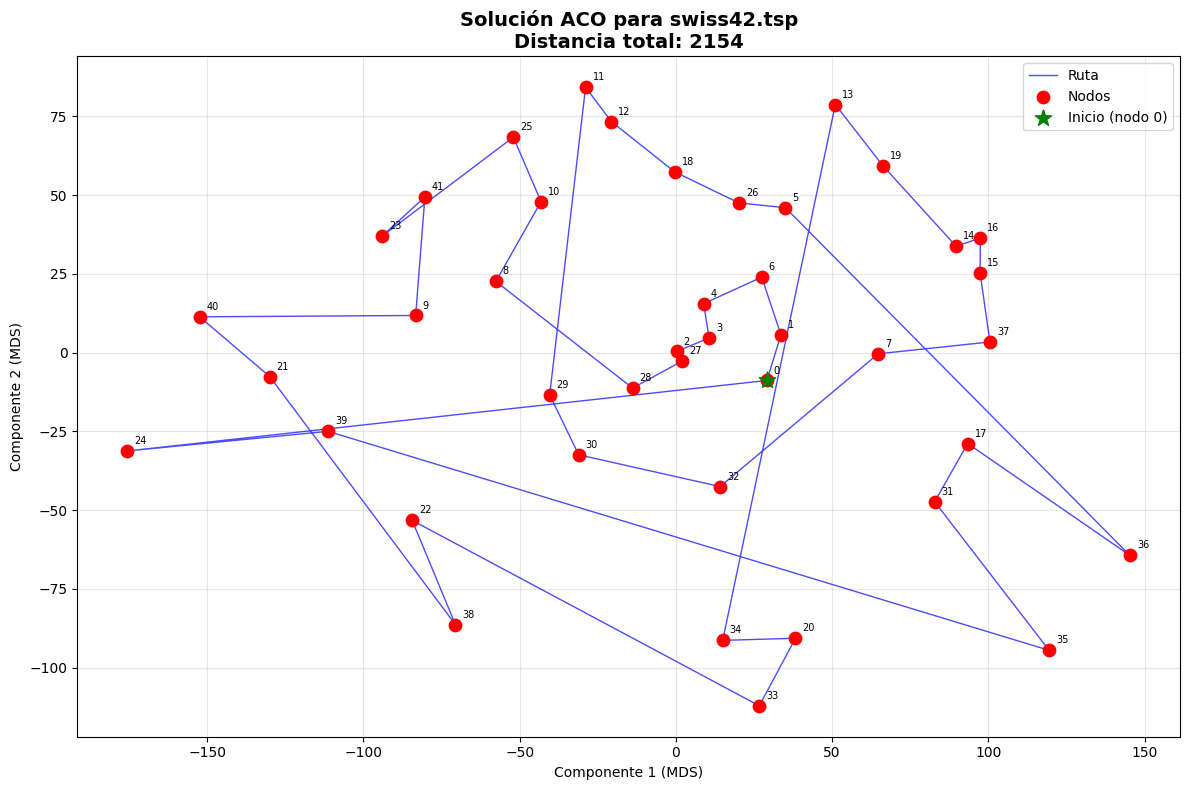

In [ ]:
def solucion_greedy(problem):
    Nodos = list(problem.get_nodes())
    no_visitados = list(range(1, len(Nodos)))
    ruta = [0]

    while no_visitados:
        nodo_actual = ruta[-1]
        # Selecciona el nodo más cercano no visitado
        siguiente = min(no_visitados, key=lambda j: distancia(nodo_actual, j, problem))
        ruta.append(siguiente)
        no_visitados.remove(siguiente)

    return ruta


def hormigas(problem, N):
    Nodos  = list(problem.get_nodes())
    n      = len(Nodos)

    # Inicialización heurística con solución greedy
    # τ_0 = 1 / (n * L_greedy) — calibra las feromonas con la escala del problema
    ruta_greedy    = solucion_greedy(problem)
    distancia_greedy = distancia_total(ruta_greedy, problem)
    tau_0          = 1.0 / (n * distancia_greedy)

    # Inicializar todas las aristas con τ_0
    T = [[tau_0 for _ in range(n)] for _ in range(n)]

    # Inicializar las hormigas, todas parten del nodo 0
    Hormiga = [[0] for _ in range(N)]

    # Construir la solución de cada hormiga
    for h in range(N):
        for i in range(n - 1):
            # Selección probabilística del siguiente nodo
            Nuevo_Nodo = Add_Nodo(problem, Hormiga[h], T)
            Hormiga[h].append(Nuevo_Nodo)

        # Incrementar feromonas según la calidad de la solución
        T = Incrementa_Feromona(problem, T, Hormiga[h])

        # Evaporación proporcional de feromonas
        T = Evaporar_Feromonas(T)

    # Seleccionar la mejor solución entre todas las hormigas
    mejor_solucion  = []
    mejor_distancia = 10e100

    for h in range(N):
        distancia_actual = distancia_total(Hormiga[h], problem)
        if distancia_actual < mejor_distancia:
            mejor_solucion  = Hormiga[h]
            mejor_distancia = distancia_actual

    print("Mejor solución:", mejor_solucion)
    print("Mejor distancia:", mejor_distancia)

    # Graficar la mejor solución encontrada
    graficar_solucion(problem, mejor_solucion, mejor_distancia)

hormigas(problem, 1000)

In [ ]:

def graficar_solucion(problem, solucion, distancia_resultado, titulo="Solución ACO para swiss42.tsp"):
    """
    Grafica la ruta usando MDS para calcular coordenadas 2D
    a partir de la matriz de distancias, ya que swiss42.tsp
    no contiene coordenadas cartesianas directas.
    """
    Nodos = list(problem.get_nodes())
    n = len(Nodos)

    # Construir matriz de distancias
    print("Construyendo matriz de distancias...")
    matriz = np.array([[distancia(i, j, problem) for j in Nodos] for i in Nodos])

    # Calcular coordenadas 2D con MDS
    print("Calculando coordenadas 2D con MDS...")
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    coordenadas = mds.fit_transform(matriz)

    # Extraer X e Y según el orden de la solución
    x = [coordenadas[nodo][0] for nodo in solucion]
    y = [coordenadas[nodo][1] for nodo in solucion]

    # Cerrar el ciclo
    x.append(x[0])
    y.append(y[0])

    # Crear figura
    fig, ax = plt.subplots(figsize=(12, 8))

    # Dibujar ruta
    ax.plot(x, y, 'b-', linewidth=1, alpha=0.7, label="Ruta")

    # Dibujar nodos
    ax.scatter(x[:-1], y[:-1], c='red', s=80, zorder=5, label="Nodos")

    # Marcar nodo inicial
    ax.scatter(x[0], y[0], c='green', s=150, zorder=6, marker='*', label="Inicio (nodo 0)")

    # Etiquetar nodos
    for i, nodo in enumerate(solucion):
        ax.annotate(str(nodo), (x[i], y[i]), textcoords="offset points",
                    xytext=(5, 5), fontsize=7, color='black')

    # Títulos y etiquetas
    ax.set_title(f"{titulo}\nDistancia total: {distancia_resultado:.0f}",
                fontsize=14, fontweight='bold')
    ax.set_xlabel("Componente 1 (MDS)")
    ax.set_ylabel("Componente 2 (MDS)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# Solución inicial con el algoritmo del vecino más cercano

"""def hormigas(problem, N) :
  #problem = datos del problema
  #N = Número de agentes(hormigas)

  #Nodos
  Nodos = list(problem.get_nodes())
  #Aristas
  Aristas = list(problem.get_edges())

  #Inicializa las aristas con una cantidad inicial de feromonas:1
  #Mejora: inicializar con valores diferentes dependiendo diferentes criterios
  T = [[ 1 for _ in range(len(Nodos)) ] for _ in range(len(Nodos))]

  #Se generan los agentes(hormigas) que serán estructuras de caminos desde 0
  Hormiga = [[0] for _ in range(N)]

  #Recorre cada agente construyendo la solución
  for h in range(N) :
    #Para cada agente se construye un camino
    for i in range(len(Nodos)-1) :

      #Elige el siguiente nodo
      Nuevo_Nodo = Add_Nodo(problem, Hormiga[h] ,T )
      Hormiga[h].append(Nuevo_Nodo)

    #Incrementa feromonas en esa arista
    T = Incrementa_Feromona(problem, T, Hormiga[h] )
    #print("Feromonas(1)", T)

    #Evapora Feromonas
    T = Evaporar_Feromonas(T)
    #print("Feromonas(2)", T)

    #Seleccionamos el mejor agente
  mejor_solucion = []
  mejor_distancia = 10e100
  for h in range(N) :
    distancia_actual = distancia_total(Hormiga[h], problem)
    if distancia_actual < mejor_distancia:
      mejor_solucion = Hormiga[h]
      mejor_distancia =distancia_actual


  print(mejor_solucion)
  print(mejor_distancia)


hormigas(problem, 1000)
"""